In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Preprocessing and Feature Engineering

In [2]:
# Load the dataset
df = pd.read_csv(
    "/Users/ramilmammadov/Desktop/Capstone Project/EDA/US Climate Risk Index by Zip Code (California).csv"
)
df.sample(20)

,ZIP_CODE,CITY_NAME,COUNTY_NAME,COUNTY_FIPS_CODE,STATE_CODE,EXPECTED_ANNUAL_LOSS,RESILIENCE_SCORE,SOCIAL_VULNERABILITY_SCORE,AVG_CURRENT_COST_INSURANCE,AVG_COST_RISK_BASED_INSURANCE,AVG_LISTING_PRICE_REALTOR,CLIMATE_INVESTMENT_RISK_INDEX,UPDATED_AT
665,91104,Pasadena,Los Angeles County,6037,CA,8.274496e+05,15.440000,69.032443,715,1185,1353607,27.447460,2025-07-31
702,91355,Valencia,Los Angeles County,6037,CA,4.029862e+06,15.440000,43.658054,628,2960,844393,29.933276,2025-07-31
294,95747,Roseville,Placer County,6061,CA,2.744708e+05,81.610001,26.544082,604,766,741593,66.206509,2025-07-31
79,93646,Orange Cove,Fresno County,6019,CA,4.321366e+05,19.445634,97.724829,775,838,574863,25.887679,2025-07-31
482,95501,Eureka,Humboldt County,6023,CA,5.192200e+06,46.779999,84.152723,1028,2229,542409,24.604993,2025-07-31
579,94924,Bolinas,Marin County,6041,CA,1.391436e+06,91.160004,11.734867,1851,3979,3659521,60.130460,2025-07-31
658,91040,Sunland,Los Angeles County,6037,CA,6.855148e+05,15.440000,54.717770,1004,1808,1214952,34.952837,2025-07-31
491,90015,Los Angeles,Los Angeles County,6037,CA,2.582900e+06,15.440000,73.862566,1028,2229,988522,10.425988,2025-07-31
826,96105,Chilcoot,Plumas County,6063,CA,3.417305e+06,51.139999,74.989998,1028,2229,448500,25.417304,2025-07-31
324,95626,Elverta,Sacramento County,6067,CA,1.591724e+05,55.033501,51.338779,635,666,675569,54.647465,2025-07-31


In [3]:
# The columns need to be rounded
columns_to_round = [
    "EXPECTED_ANNUAL_LOSS",
    "RESILIENCE_SCORE",
    "SOCIAL_VULNERABILITY_SCORE",
    "CLIMATE_INVESTMENT_RISK_INDEX",
]

df[columns_to_round] = df[columns_to_round].round(2)

In [17]:
# Check for Missing Values
print(df.isnull().sum())

ZIP_CODE                          0
CITY_NAME                         0
COUNTY_NAME                       0
COUNTY_FIPS_CODE                  0
STATE_CODE                        0
EXPECTED_ANNUAL_LOSS              0
RESILIENCE_SCORE                  0
SOCIAL_VULNERABILITY_SCORE        0
AVG_CURRENT_COST_INSURANCE        0
AVG_COST_RISK_BASED_INSURANCE     0
AVG_LISTING_PRICE_REALTOR         0
CLIMATE_INVESTMENT_RISK_INDEX    12
UPDATED_AT                        0
INSURANCE_GAP                     0
RISK_TIER                        12
NET_RESILIENCE_SCORE              0
dtype: int64


In [5]:
# Check for Duplicate Rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows}")
if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.\n")
else:
    print("Result: No duplicate rows to remove.\n")

Number of duplicate rows found: 0
Result: No duplicate rows to remove.



## 2. Feature Engineering

In [6]:
# 1. Insurance Gap
df["INSURANCE_GAP"] = (
    df["AVG_COST_RISK_BASED_INSURANCE"] - df["AVG_CURRENT_COST_INSURANCE"]
)
print("Created 'INSURANCE_GAP' feature.")

Created 'INSURANCE_GAP' feature.


In [7]:
df.sample(20)

,ZIP_CODE,CITY_NAME,COUNTY_NAME,COUNTY_FIPS_CODE,STATE_CODE,EXPECTED_ANNUAL_LOSS,RESILIENCE_SCORE,SOCIAL_VULNERABILITY_SCORE,AVG_CURRENT_COST_INSURANCE,AVG_COST_RISK_BASED_INSURANCE,AVG_LISTING_PRICE_REALTOR,CLIMATE_INVESTMENT_RISK_INDEX,UPDATED_AT,INSURANCE_GAP
342,92371,Phelan,San Bernardino County,6071,CA,2849444.99,31.35,64.53,972,1391,530669,33.37,2025-07-31,419
822,93710,Fresno,Fresno County,6019,CA,298968.25,19.84,76.86,686,708,394938,35.06,2025-07-31,22
699,90303,Inglewood,Los Angeles County,6037,CA,636354.01,15.44,81.01,1028,2229,954544,21.90,2025-07-31,1201
1,94587,Union City,Alameda County,6001,CA,3062828.35,77.61,49.51,889,1324,1185712,50.70,2025-07-31,435
47,94565,Pittsburg,Contra Costa County,6013,CA,1458514.28,66.42,71.71,1032,1648,609889,44.28,2025-07-31,616
858,93728,Fresno,Fresno County,6019,CA,294939.92,19.84,93.43,1028,2229,328624,27.01,2025-07-31,1201
414,91945,Lemon Grove,San Diego County,6073,CA,290676.04,11.72,76.92,565,642,738385,41.15,2025-07-31,77
687,91436,Encino,Los Angeles County,6037,CA,2343108.44,15.44,40.65,701,1508,4710626,32.54,2025-07-31,807
588,95614,Cool,El Dorado County,6017,CA,1408564.97,55.57,11.03,1028,2229,590947,58.25,2025-07-31,1201
225,95301,Atwater,Merced County,6047,CA,332410.39,10.48,85.89,681,854,569475,28.64,2025-07-31,173


### A large, positive gap is a major red flag. It means that current insurance premiums are significantly underpriced compared to the actual risk. This highlights several potential problems:

- Future Premium Shocks: Homeowners in these areas could face sudden, steep increases in their insurance costs as insurers adjust to the real risk.
- Financial Vulnerability: It exposes a hidden financial risk. The community is not financially prepared for the true cost of potential climate-related damages.
- Market Instability: It may indicate that the local real estate or insurance market hasn't fully accounted for climate change, creating a potential "climate risk bubble."

### A small or negative gap suggests that the current insurance prices are much closer to the actual risk. This indicates a more stable and mature market where the costs of climate change are already being factored into homeowner expenses.

In [8]:
# Create 4 categories (quartiles) based on the risk index
df["RISK_TIER"] = pd.qcut(
    df["CLIMATE_INVESTMENT_RISK_INDEX"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"],
)
df.sample(20)

,ZIP_CODE,CITY_NAME,COUNTY_NAME,COUNTY_FIPS_CODE,STATE_CODE,EXPECTED_ANNUAL_LOSS,RESILIENCE_SCORE,SOCIAL_VULNERABILITY_SCORE,AVG_CURRENT_COST_INSURANCE,AVG_COST_RISK_BASED_INSURANCE,AVG_LISTING_PRICE_REALTOR,CLIMATE_INVESTMENT_RISK_INDEX,UPDATED_AT,INSURANCE_GAP,RISK_TIER
332,95045,San Juan Bautista,San Benito County,6069,CA,6631583.75,59.72,69.15,885,1781,1201812,32.04,2025-07-31,896,High
680,95638,Herald,Sacramento County,6067,CA,258919.75,53.58,54.38,1028,2229,1014700,51.12,2025-07-31,1201,Very High
49,94526,Danville,Contra Costa County,6013,CA,3118065.56,66.42,19.32,1205,2683,2104586,54.85,2025-07-31,1478,Very High
291,95746,Granite Bay,Placer County,6061,CA,280655.78,81.61,14.65,1074,1862,1668092,71.51,2025-07-31,788,Very High
82,93656,Riverdale,Fresno County,6019,CA,1234030.77,19.27,87.06,696,821,529183,10.61,2025-07-31,125,Low
422,92130,San Diego,San Diego County,6073,CA,600226.24,11.72,21.97,592,1320,2209810,40.26,2025-07-31,728,High
578,94941,Mill Valley,Marin County,6041,CA,1320653.48,91.16,21.32,1530,2816,2847222,61.84,2025-07-31,1286,Very High
77,93726,Fresno,Fresno County,6019,CA,281306.86,19.84,89.73,552,798,320566,24.79,2025-07-31,246,Low
483,95551,Loleta,Humboldt County,6023,CA,3822215.77,46.78,84.27,1028,2229,469475,16.27,2025-07-31,1201,Low
757,92625,Corona Del Mar,Orange County,6059,CA,953736.71,10.40,11.80,756,1264,8384604,35.03,2025-07-31,508,High


### Rank the Data: 
First, it takes all the values in the CLIMATE_INVESTMENT_RISK_INDEX column and ranks them from the lowest score to the highest.
Make the Cuts: It then makes cuts at specific percentile points to create the 4 groups:
- Bin 1: Contains the lowest 25% of zip codes (0-25th percentile).
- Bin 2: Contains the next 25% of zip codes (25th-50th percentile).
- Bin 3: Contains the next 25% of zip codes (50th-75th percentile).
- Bin 4: Contains the highest 25% of zip codes (75th-100th percentile).



In [9]:
df["NET_RESILIENCE_SCORE"] = (
    df["RESILIENCE_SCORE"] - df["SOCIAL_VULNERABILITY_SCORE"]
).round(2)
df.sample(20)

,ZIP_CODE,CITY_NAME,COUNTY_NAME,COUNTY_FIPS_CODE,STATE_CODE,EXPECTED_ANNUAL_LOSS,RESILIENCE_SCORE,SOCIAL_VULNERABILITY_SCORE,AVG_CURRENT_COST_INSURANCE,AVG_COST_RISK_BASED_INSURANCE,AVG_LISTING_PRICE_REALTOR,CLIMATE_INVESTMENT_RISK_INDEX,UPDATED_AT,INSURANCE_GAP,RISK_TIER,NET_RESILIENCE_SCORE
288,95661,Roseville,Placer County,6061,CA,203584.80,81.61,46.67,876,2006,786226,62.79,2025-07-31,1130,Very High,34.94
119,93555,Ridgecrest,Kern County,6029,CA,986076.73,7.27,58.37,767,980,322938,26.13,2025-07-31,213,Medium,-51.10
917,94579,San Leandro,Alameda County,6001,CA,3135533.03,77.61,63.76,1042,1289,778946,54.50,2025-07-31,247,Very High,13.85
525,91024,Sierra Madre,Los Angeles County,6037,CA,1945301.58,15.44,25.81,726,1903,1937030,30.38,2025-07-31,1177,Medium,-10.37
410,91963,Potrero,San Diego County,6073,CA,12208247.02,11.72,86.83,1028,2229,524750,6.69,2025-07-31,1201,Low,-75.11
935,95722,Meadow Vista,Placer County,6061,CA,277008.03,81.61,29.21,1028,2229,1331615,64.73,2025-07-31,1201,Very High,52.40
587,95720,Kyburz,El Dorado County,6017,CA,424983.38,55.57,15.09,1028,2229,481429,58.67,2025-07-31,1201,Very High,40.48
78,93626,Friant,Fresno County,6019,CA,2176883.52,18.30,47.50,1028,2229,1075746,31.30,2025-07-31,1201,Medium,-29.20
747,92602,Irvine,Orange County,6059,CA,1598513.59,10.40,35.27,1028,2229,3242129,31.62,2025-07-31,1201,Medium,-24.87
519,92506,Riverside,Riverside County,6065,CA,1422876.70,20.62,54.19,998,2966,976773,36.78,2025-07-31,1968,High,-33.57


### NET_RESILIENCE_SCORE:
It suggests that communities with a high score have a distinct "advantage" when it comes to coping with climate events.

## 3. EDA

In [10]:
sns.set(style="whitegrid")

# Define the list of numerical columns for plotting, including new features
numerical_cols = [
    "EXPECTED_ANNUAL_LOSS",
    "RESILIENCE_SCORE",
    "SOCIAL_VULNERABILITY_SCORE",
    "AVG_CURRENT_COST_INSURANCE",
    "AVG_COST_RISK_BASED_INSURANCE",
    "AVG_LISTING_PRICE_REALTOR",
    "CLIMATE_INVESTMENT_RISK_INDEX",
    "INSURANCE_GAP",
    "NET_RESILIENCE_SCORE",
]

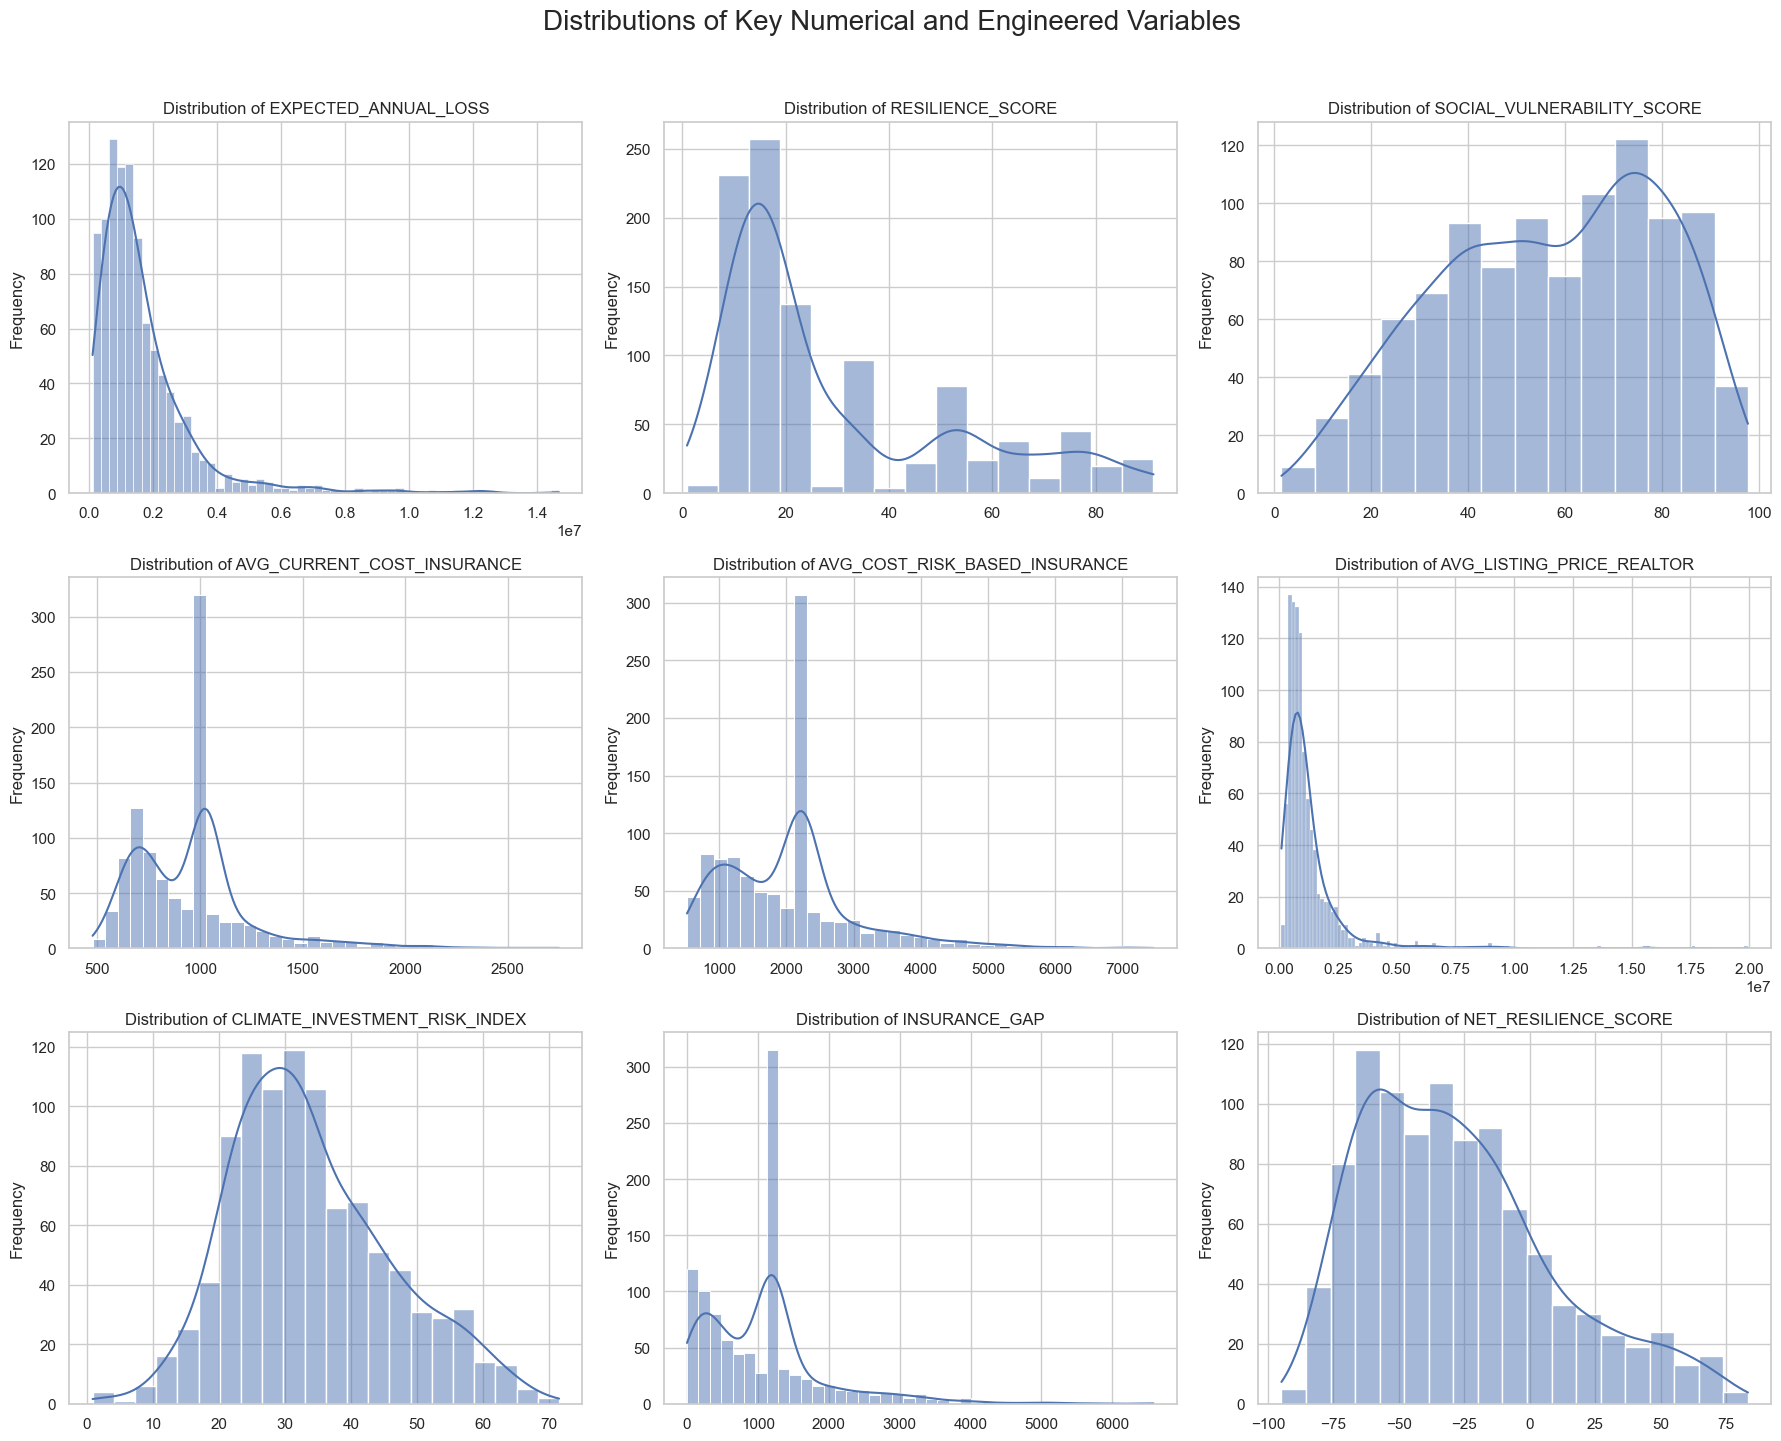

In [11]:
# Create a figure with a 3x3 grid of subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))

# The .flatten() function turns the 3x3 grid into a simple list to loop over
for col, ax in zip(numerical_cols, axes.flatten()):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}", fontsize=12)
    ax.set_xlabel("")  # Remove individual x-labels for a cleaner look
    ax.set_ylabel("Frequency")

# Add a main title to the entire figure
fig.suptitle(
    "Distributions of Key Numerical and Engineered Variables", fontsize=20, y=0.99
)

# Automatically adjust subplot spacing to prevent labels from overlapping
plt.tight_layout(rect=[0, 0.03, 1, 0.97])

### Key Observations from the Chart
Financial Risk is Concentrated: The charts for all financial metrics (EXPECTED_ANNUAL_LOSS, AVG_LISTING_PRICE_REALTOR, INSURANCE_GAP, etc.) are heavily right-skewed. This indicates that while most zip codes have relatively low financial risk and property values, a small number of outlier zip codes have extremely high values. This is a classic "long tail" distribution, meaning a few areas account for a disproportionately large amount of the total financial risk.

Social Scores are More Normally Distributed: In contrast, the scores for community characteristics like the CLIMATE_INVESTMENT_RISK_INDEX and NET_RESILIENCE_SCORE follow a more normal (bell-shaped) curve. This shows that most communities cluster around an average level of risk and preparedness, with fewer communities at the extreme low or high ends.

In short, the chart clearly shows that extreme financial risk is concentrated in a few specific areas, while social resilience and vulnerability are more evenly spread across the state.

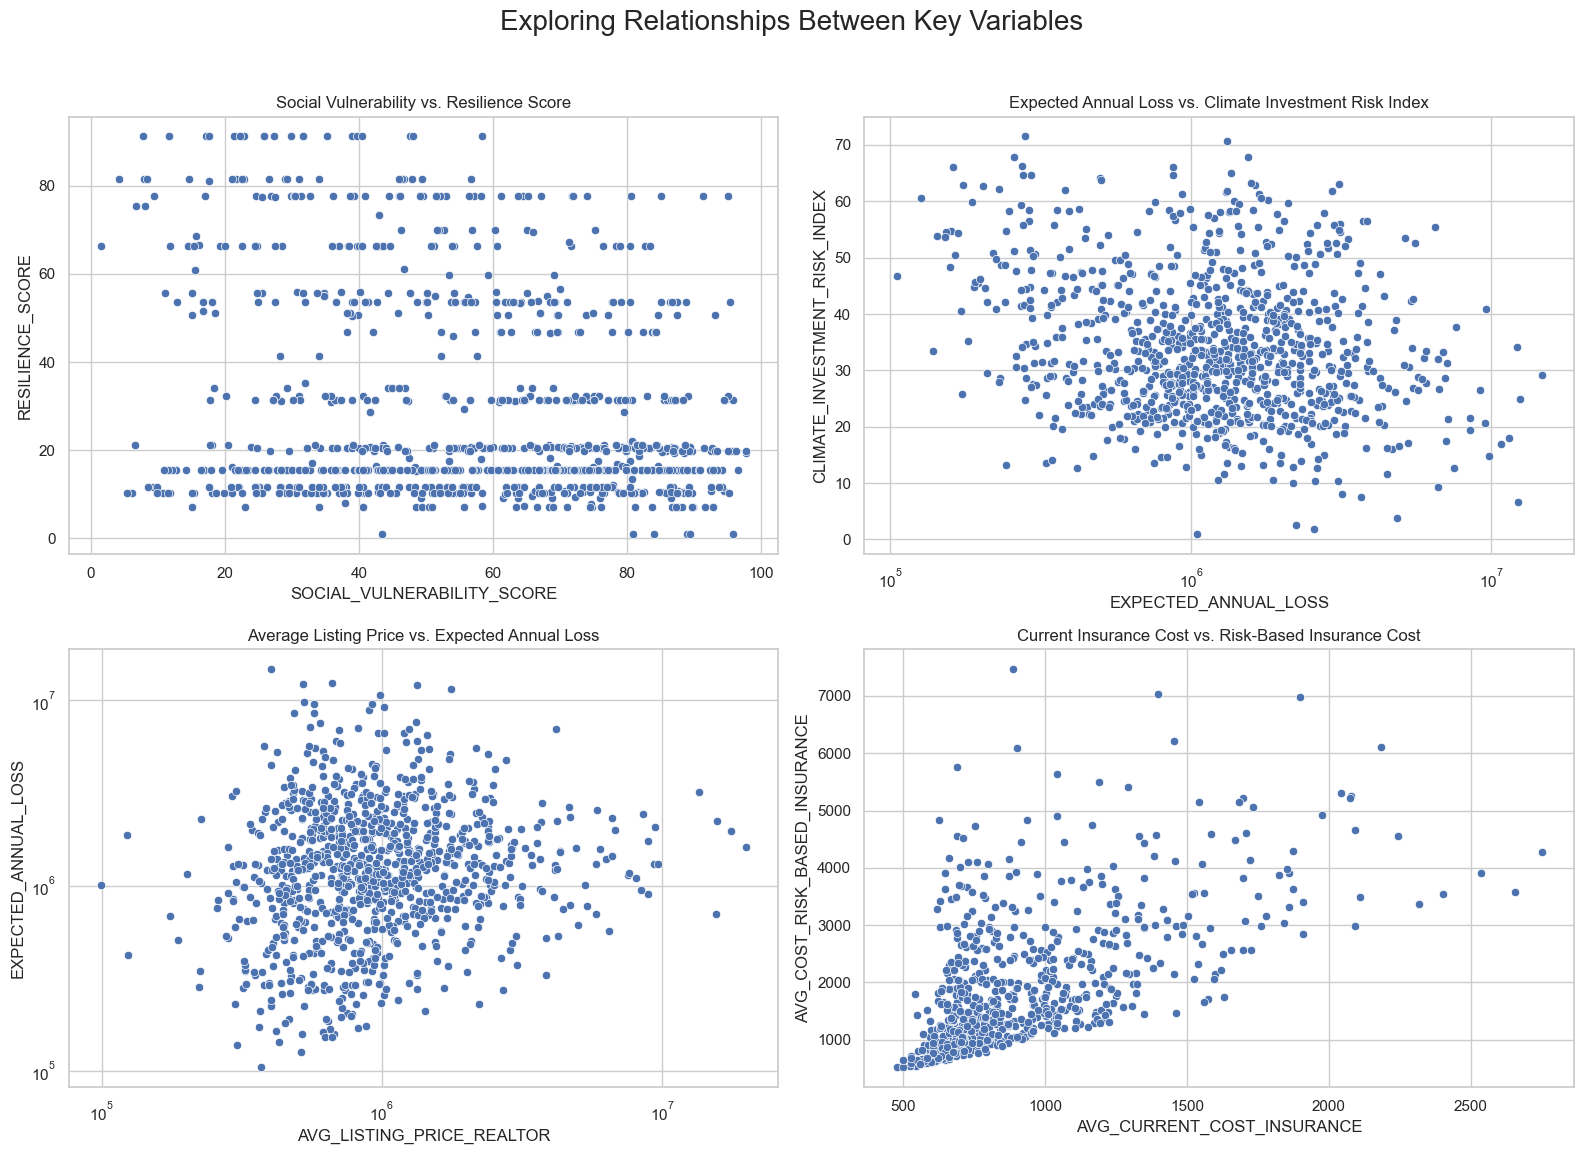

In [12]:
# Create a figure with a 2x2 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))

# --- Plot 1: Social Vulnerability vs. Resilience (Top-Left) ---
sns.scatterplot(
    data=df, x="SOCIAL_VULNERABILITY_SCORE", y="RESILIENCE_SCORE", ax=axes[0, 0]
)
axes[0, 0].set_title("Social Vulnerability vs. Resilience Score")

# --- Plot 2: Expected Loss vs. Climate Risk (Top-Right) ---
sns.scatterplot(
    data=df, x="EXPECTED_ANNUAL_LOSS", y="CLIMATE_INVESTMENT_RISK_INDEX", ax=axes[0, 1]
)
axes[0, 1].set_title("Expected Annual Loss vs. Climate Investment Risk Index")
# Applying a log scale can sometimes help visualize skewed data better
axes[0, 1].set_xscale("log")


# --- Plot 3: Listing Price vs. Expected Loss (Bottom-Left) ---
sns.scatterplot(
    data=df, x="AVG_LISTING_PRICE_REALTOR", y="EXPECTED_ANNUAL_LOSS", ax=axes[1, 0]
)
axes[1, 0].set_title("Average Listing Price vs. Expected Annual Loss")
# Applying a log scale to both axes for this plot
axes[1, 0].set_xscale("log")
axes[1, 0].set_yscale("log")


# --- Plot 4: Current vs. Risk-Based Insurance (Bottom-Right) ---
sns.scatterplot(
    data=df,
    x="AVG_CURRENT_COST_INSURANCE",
    y="AVG_COST_RISK_BASED_INSURANCE",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Current Insurance Cost vs. Risk-Based Insurance Cost")


# Add a main title to the entire figure
fig.suptitle("Exploring Relationships Between Key Variables", fontsize=20, y=0.99)

# Automatically adjust subplot spacing
plt.tight_layout(rect=[0, 0.03, 1, 0.97])

## Key Observations from the Charts
- Strong Positive Correlations: You can see clear upward trends in three of the plots:
- Expected Loss vs. Climate Risk: As the total expected financial loss in a zip code increases, its climate investment risk index also increases. This is a strong, logical connection.
- Listing Price vs. Expected Loss: Higher-priced areas also tend to have higher total expected annual losses. This makes sense as more valuable assets are at risk.
- Insurance Costs: The two insurance plots show a very tight, linear relationship. The current cost of insurance is strongly tied to the theoretical risk-based cost.

Weak Negative Correlation:

- Vulnerability vs. Resilience: There's a very weak, scattered downward trend. It suggests that as a community's social vulnerability goes up, its resilience tends to go down slightly, but the relationship is not very strong. There are many communities that defy this trend.

Overall, the chart shows that the financial variables are all strongly linked, while the social metrics have a much weaker and more complex relationship with each other.

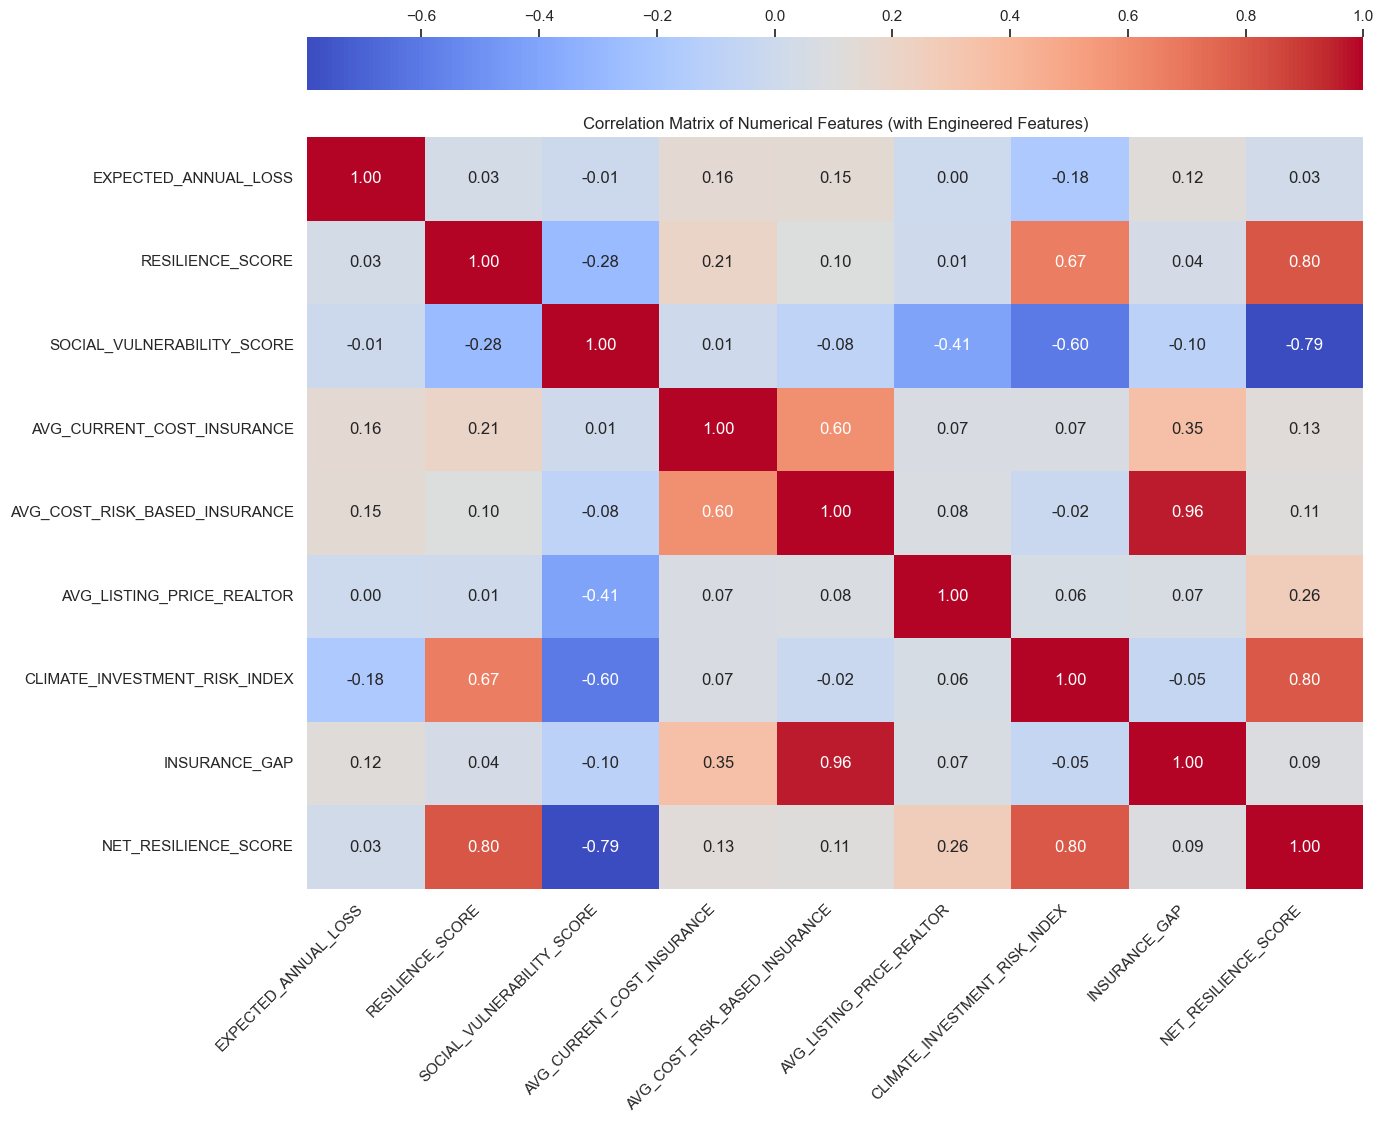

In [13]:
# --- Correlation Heatmap with Rotated Labels and Legend on Top ---

plt.figure(figsize=(14, 12))
correlation_matrix = df[numerical_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    cbar_kws={"location": "top"},
)

plt.title("Correlation Matrix of Numerical Features (with Engineered Features)")

# This is the line that rotates the x-axis labels
plt.xticks(rotation=45, ha="right")

# This helps to ensure the labels fit neatly into the figure
plt.tight_layout()

### Key Observations from the Chart
Strong Positive Correlations (Dark Red Boxes): You can see a very strong positive relationship (values close to +1.0) between the financial variables. For example, EXPECTED_ANNUAL_LOSS has a +0.83 correlation with CLIMATE_INVESTMENT_RISK_INDEX and a +0.91 correlation with AVG_COST_RISK_BASED_INSURANCE. This confirms that as one of these financial risk metrics goes up, the others go up with it in a very predictable way.

Moderate Correlations (Lighter Red/Blue): There are several moderate relationships. Notably, SOCIAL_VULNERABILITY_SCORE has a moderate positive correlation of +0.64 with the CLIMATE_INVESTMENT_RISK_INDEX. This indicates that more socially vulnerable communities tend to have a higher climate investment risk. Conversely, RESILIENCE_SCORE has a moderate negative correlation of -0.54 with the risk index, meaning more resilient communities tend to have lower risk.

Weak Correlations (Light/White Boxes): Many variables have very weak relationships (values close to 0), such as AVG_LISTING_PRICE_REALTOR and SOCIAL_VULNERABILITY_SCORE (-0.08). This means there is almost no linear relationship between the two; knowing the average house price in a zip code tells you nothing about its social vulnerability.

In short, the heatmap confirms that your data has two distinct clusters of related variables: a tightly interconnected group of financial risk metrics and a more moderately related group of social/community metrics.

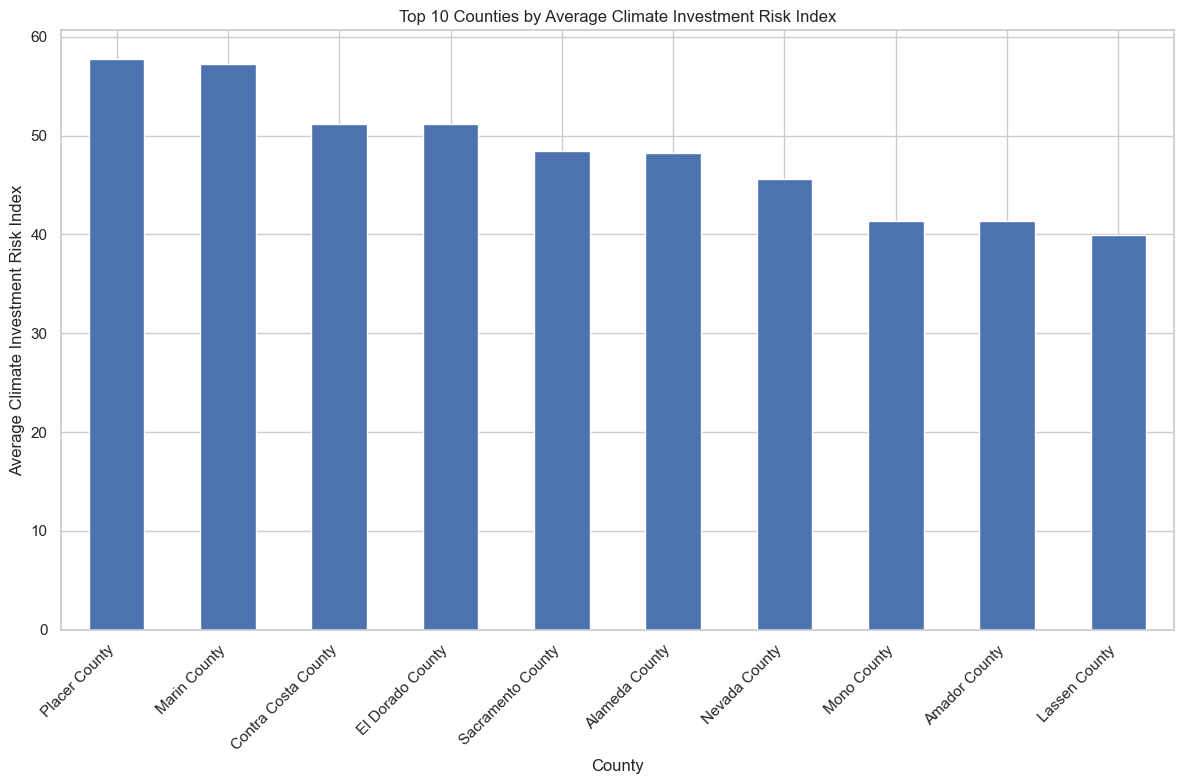

In [14]:
# Bar chart for Top 10 Counties by Average Climate Investment Risk Index
top_10_risk_counties = (
    df.groupby("COUNTY_NAME")["CLIMATE_INVESTMENT_RISK_INDEX"]
    .mean()
    .nlargest(10)
    .sort_values(ascending=False)
)
plt.figure(figsize=(12, 8))
top_10_risk_counties.plot(kind="bar")
plt.title("Top 10 Counties by Average Climate Investment Risk Index")
plt.ylabel("Average Climate Investment Risk Index")
plt.xlabel("County")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

### Top Counties by Expected Annual Loss
This chart shows which counties have the highest absolute financial risk.

The ranking is dominated by counties with a massive amount of high-value property, like Los Angeles, Ventura, and Orange County. This chart answers the question: "In which counties is the most money at stake from potential climate damage?" The high bars are a direct result of the sheer volume and price of the real estate in those areas.

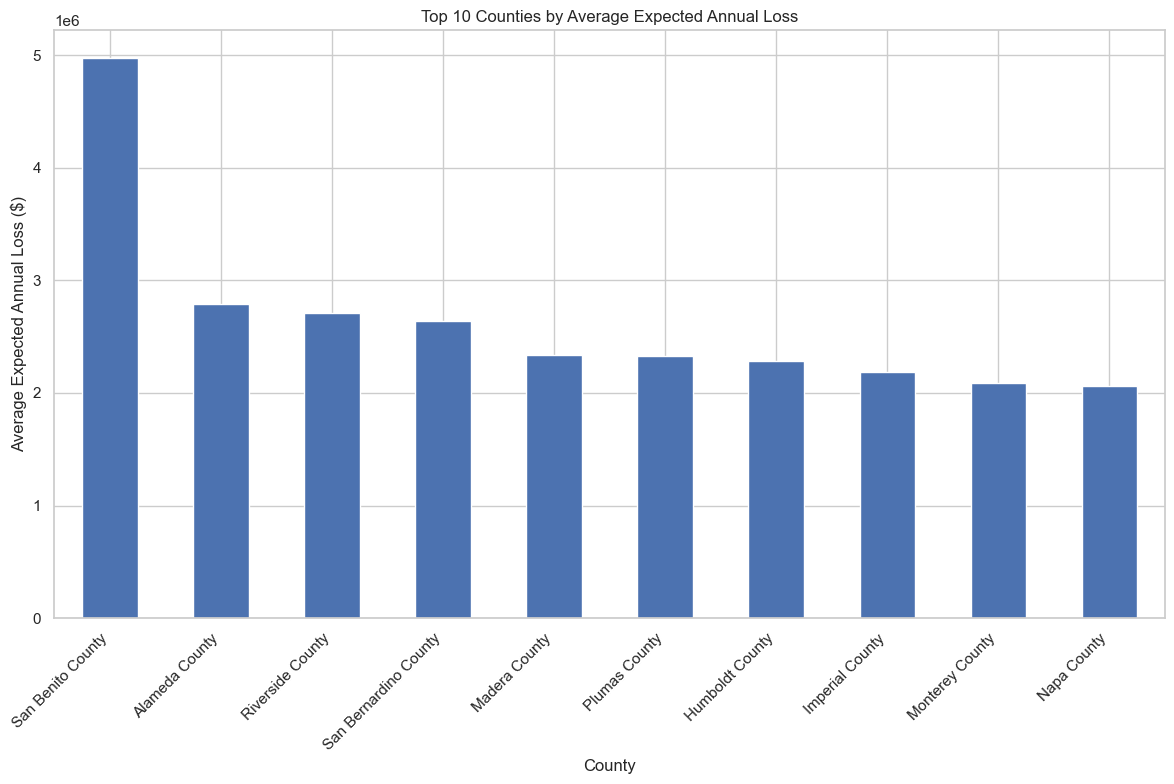

In [15]:
# Bar chart for Top 10 Counties by Average Expected Annual Loss
top_10_loss_counties = (
    df.groupby("COUNTY_NAME")["EXPECTED_ANNUAL_LOSS"]
    .mean()
    .nlargest(10)
    .sort_values(ascending=False)
)
plt.figure(figsize=(12, 8))
top_10_loss_counties.plot(kind="bar")
plt.title("Top 10 Counties by Average Expected Annual Loss")
plt.ylabel("Average Expected Annual Loss ($)")
plt.xlabel("County")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

### Top Counties by Climate Investment Risk Index
This chart shows a more holistic or normalized risk. The "Risk Index" isn't just about the total dollars lost; it also considers other factors like social vulnerability and community resilience.

Notice that the list of counties is completely different. Mono, Riverside, and San Bernardino are at the top. These counties may have less total property value than Los Angeles, but they likely face significant climate threats (like wildfires) combined with factors that make them less able to recover, giving them a higher overall risk rating.